In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

PROJECT = "/content/drive/MyDrive/delivery_delay_project"
PROC    = f"{PROJECT}/data/processed"
MODELS  = f"{PROJECT}/models"

import os
os.makedirs(MODELS, exist_ok=True)

df = pd.read_csv(f"{PROC}/delivery_clean.csv")
print(f"✅ Loaded: {df.shape}")
df.head(3)

Mounted at /content/drive
✅ Loaded: (45593, 27)


,id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_orderd,...,festival,city,time_taken,city_code,distance_km,order_hour,is_peak_hour,rain_flag,festival_flag,distance_bucket
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,No,Urban,24.0,INDO,3.025149,11.0,0,0,0,short
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,No,Metropolitian,33.0,BANG,20.183530,19.0,1,0,0,very_long
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,No,Urban,26.0,BANG,1.552758,8.0,0,0,0,very_short


In [3]:
# ════════════════════════════════════════════
#   ALWAYS RUN THIS CELL FIRST — EVERY TIME
# ════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')

PROJECT = "/content/drive/MyDrive/delivery_delay_project"
RAW     = f"{PROJECT}/data/raw"
PROC    = f"{PROJECT}/data/processed"
MODELS  = f"{PROJECT}/models"

for path in [RAW, PROC, MODELS]:
    os.makedirs(path, exist_ok=True)

print("✅ Drive mounted & paths ready!")
print(f"   Files in RAW folder: {os.listdir(RAW)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted & paths ready!
   Files in RAW folder: ['train.csv', 'india_festivals.xlsx', 'API of weather.txt', 'weather_live (2).xlsx', 'zomato dataset', 'main dataset', 'Historical Weather Data for Indian Cities dataset']


In [4]:
import pandas as pd
df = pd.read_csv(f"{RAW}/train.csv")
df.sample(500, random_state=42).to_csv(
    f"{PROJECT}/sample_data.csv", index=False)
print("Saved 500 row sample")

Saved 500 row sample


In [ ]:
# Reload fresh from raw file to avoid any name corruption
df = pd.read_csv(f"{RAW}/train.csv")

# See EXACT column names with repr (catches hidden spaces/special chars)
for col in df.columns:
    print(repr(col))

'ID'
'Delivery_person_ID'
'Delivery_person_Age'
'Delivery_person_Ratings'
'Restaurant_latitude'
'Restaurant_longitude'
'Delivery_location_latitude'
'Delivery_location_longitude'
'Order_Date'
'Time_Orderd'
'Time_Order_picked'
'Weatherconditions'
'Road_traffic_density'
'Vehicle_condition'
'Type_of_order'
'Type_of_vehicle'
'multiple_deliveries'
'Festival'
'City'
'Time_taken(min)'


In [ ]:
import pandas as pd
import numpy as np
import warnings, os, math
warnings.filterwarnings('ignore')

# ── Reload raw file fresh ──────────────────────────────────────
df = pd.read_csv(f"{RAW}/train.csv")

# ── Step 1: Find & fix the time column automatically ──────────
# Find whichever column contains 'time_taken' (case-insensitive)
time_col = [c for c in df.columns if 'time_taken' in c.lower()][0]
print(f"✅ Found time column: {repr(time_col)}")

# Extract number from strings like "(min) 24" or "24"
df['time_taken'] = df[time_col].astype(str)\
                     .str.extract(r'(\d+\.?\d*)')[0]\
                     .astype(float)

print(f"   Sample values: {df['time_taken'].head().tolist()}")

# ── Step 2: Fix weather column ─────────────────────────────────
weather_col = [c for c in df.columns if 'weather' in c.lower()][0]
print(f"✅ Found weather column: {repr(weather_col)}")

df['weather'] = df[weather_col]\
                  .astype(str)\
                  .str.replace("conditions ", "", regex=False)\
                  .str.strip()

# ── Step 3: Distance (Haversine) ───────────────────────────────
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1,lon1,lat2,lon2 = map(math.radians,[lat1,lon1,lat2,lon2])
    dlat = lat2-lat1; dlon = lon2-lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return 2*R*math.asin(math.sqrt(a))

df['distance_km'] = df.apply(lambda r: haversine(
    r['Restaurant_latitude'],          r['Restaurant_longitude'],
    r['Delivery_location_latitude'],   r['Delivery_location_longitude']), axis=1)

# ── Step 4: Time features ──────────────────────────────────────
time_order_col = [c for c in df.columns if 'time_orderd' in c.lower()][0]
df['order_hour'] = pd.to_datetime(
    df[time_order_col], errors='coerce').dt.hour.fillna(12).astype(int)

df['is_peak_hour'] = df['order_hour'].apply(
    lambda h: 1 if h in list(range(12,14))+list(range(19,22)) else 0)

# ── Step 5: Flag features ──────────────────────────────────────
df['rain_flag']    = df['weather'].str.lower()\
                       .str.contains('rain', na=False).astype(int)
df['festival_flag']= (df['Festival'].str.strip().str.lower()=='yes').astype(int)
df['multi_delivery']= pd.to_numeric(df['multiple_deliveries'], errors='coerce').fillna(0).astype(int)

# ── Step 6: Encode categoricals ────────────────────────────────
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['traffic_enc'] = le.fit_transform(df['Road_traffic_density'].astype(str))
df['weather_enc'] = le.fit_transform(df['weather'].astype(str))
df['city_enc']    = le.fit_transform(df['City'].astype(str))
df['vehicle_enc'] = le.fit_transform(df['Type_of_vehicle'].astype(str))

# ── Step 7: Impute remaining NaNs in features ──────────────────
# Impute NaNs in numerical feature columns with their median
for col in ['Delivery_person_Age', 'Delivery_person_Ratings', 'Vehicle_condition']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce') # Convert to numeric first
        df[col] = df[col].fillna(df[col].median()) # Then fill NaNs with the median

# ── Final check ────────────────────────────────────────────────
print(f"\n✅ All features ready! Shape: {df.shape}")
print(df[['distance_km','rain_flag','is_peak_hour',
          'festival_flag','traffic_enc','time_taken']].head())

✅ Found time column: 'Time_taken(min)'
   Sample values: [24.0, 33.0, 26.0, 21.0, 30.0]
✅ Found weather column: 'Weatherconditions'

✅ All features ready! Shape: (45593, 32)
   distance_km  rain_flag  is_peak_hour  festival_flag  traffic_enc  \
0     3.025149          0             0              0            0   
1    20.183530          0             1              0            1   
2     1.552758          0             0              0            2   
3     7.790401          0             0              0            3   
4     6.210138          0             1              0            0   

   time_taken  
0        24.0  
1        33.0  
2        26.0  
3        21.0  
4        30.0  


In [ ]:
FEATURES = [
    'Delivery_person_Age',
    'Delivery_person_Ratings',
    'distance_km',
    'order_hour',
    'is_peak_hour',
    'rain_flag',
    'festival_flag',
    'multi_delivery',
    'Vehicle_condition',
    'traffic_enc',
    'weather_enc',
    'city_enc',
    'vehicle_enc',
]

X = df[FEATURES]
y = df['time_taken']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"✅ Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"   Target mean: {y.mean():.1f} min  |  std: {y.std():.1f} min")

✅ Train: (36474, 13)  |  Test: (9119, 13)
   Target mean: 26.3 min  |  std: 9.4 min


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np # Import numpy for sqrt

def evaluate(name, y_true, y_pred):
    # Calculate MSE first, then take square root for RMSE
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n📊 {name}")
    print(f"   RMSE : {rmse:.2f} min")
    print(f"   MAE  : {mae:.2f} min")
    print(f"   R²   : {r2:.4f}")
    return {'Model': name, 'RMSE': round(rmse,2),
            'MAE': round(mae,2), 'R2': round(r2,4)}

results = []

lr = LinearRegression()
lr.fit(X_train, y_train)
results.append(evaluate("Linear Regression", y_test, lr.predict(X_test)))


📊 Linear Regression
   RMSE : 6.72 min
   MAE  : 5.36 min
   R²   : 0.4849


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate("Random Forest", y_test, rf.predict(X_test)))


📊 Random Forest
   RMSE : 4.09 min
   MAE  : 3.23 min
   R²   : 0.8090


In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    n_jobs           = -1
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=50)

results.append(evaluate("XGBoost", y_test, xgb.predict(X_test)))

[0]	validation_0-rmse:9.08555
[50]	validation_0-rmse:4.36359
[100]	validation_0-rmse:4.05073
[150]	validation_0-rmse:4.00552
[200]	validation_0-rmse:3.99711
[250]	validation_0-rmse:3.98646
[299]	validation_0-rmse:3.98473

📊 XGBoost
   RMSE : 3.98 min
   MAE  : 3.17 min
   R²   : 0.8189



🏆 Model Leaderboard
            Model  RMSE  MAE     R2
          XGBoost  3.98 3.17 0.8189
    Random Forest  4.09 3.23 0.8090
Linear Regression  6.72 5.36 0.4849


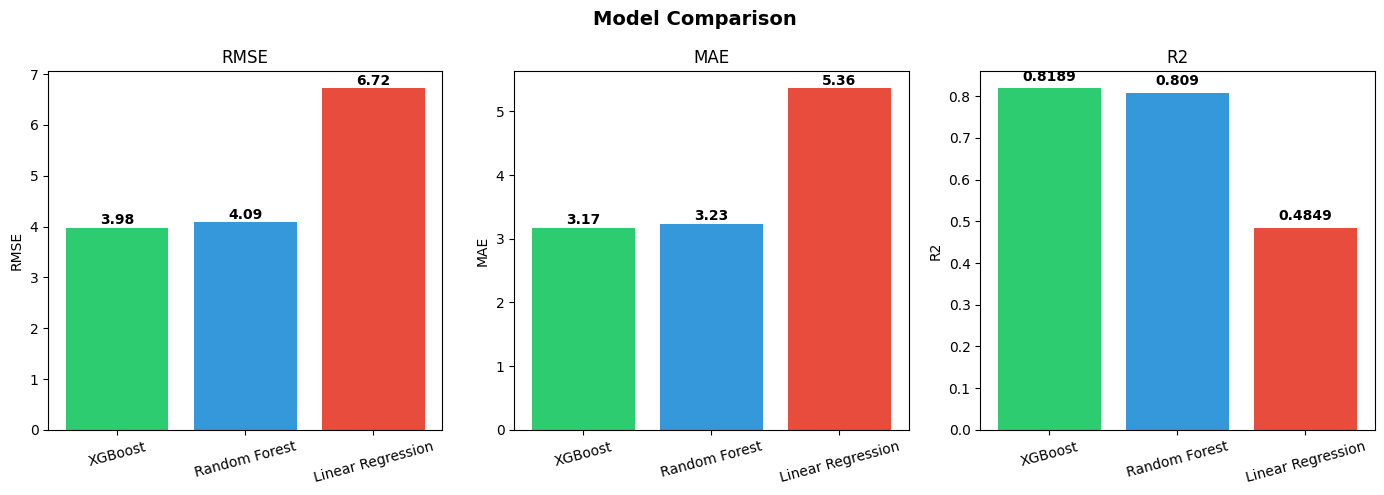

In [ ]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results).sort_values('RMSE')

print("\n🏆 Model Leaderboard")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Model Comparison", fontsize=14, fontweight='bold')

colors = ['#2ecc71' if i==0 else '#3498db' if i==1 else '#e74c3c'
          for i in range(len(results_df))]

for i, (metric, ax) in enumerate(zip(['RMSE','MAE','R2'], axes)):
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.01, str(val),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{PROJECT}/model_comparison.png", dpi=150)
plt.show()

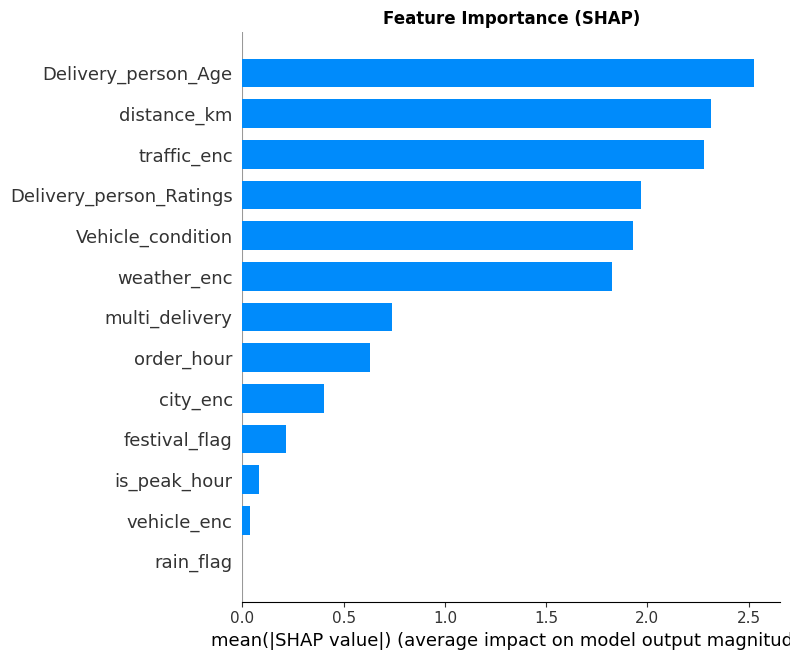

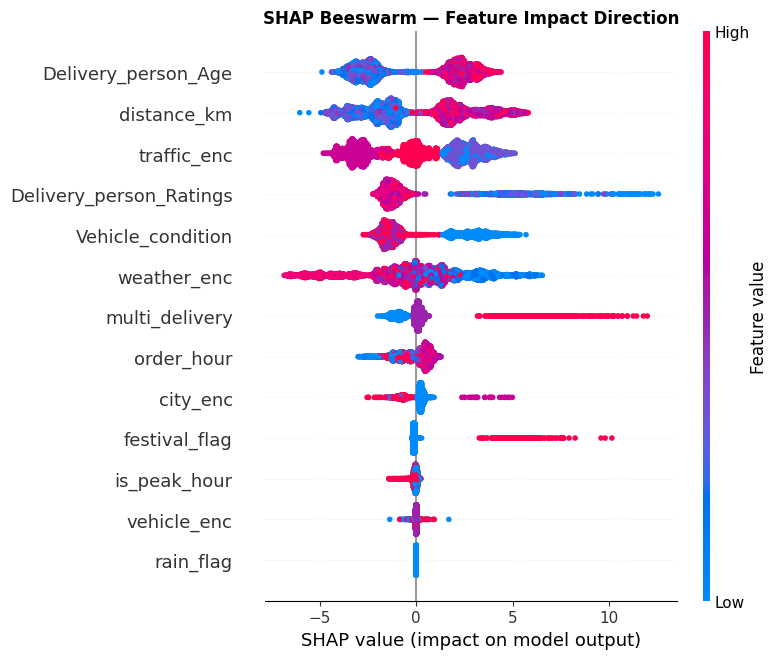

✅ SHAP plots saved!


In [ ]:
!pip install shap -q

import shap

explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Plot 1 — Feature importance bar chart
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test,
                  plot_type='bar', show=False)
plt.title("Feature Importance (SHAP)", fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PROJECT}/shap_importance.png", dpi=150, bbox_inches='tight')
plt.show()

# Plot 2 — Beeswarm (shows direction of impact)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Beeswarm — Feature Impact Direction", fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PROJECT}/shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ SHAP plots saved!")

In [ ]:
import pickle

# Save XGBoost (best model)
with open(f"{MODELS}/xgboost_model.pkl", 'wb') as f:
    pickle.dump(xgb, f)

# Save Random Forest
with open(f"{MODELS}/random_forest_model.pkl", 'wb') as f:
    pickle.dump(rf, f)

# Save results table
results_df.to_csv(f"{PROJECT}/model_results.csv", index=False)

print("✅ All models saved to Google Drive!")
print(f"📁 {MODELS}/")

✅ All models saved to Google Drive!
📁 /content/drive/MyDrive/delivery_delay_project/models/


In [ ]:
import numpy as np

# Simulate a real order: rainy evening in Mumbai, 5km away
sample_order = pd.DataFrame([{
    'Delivery_person_Age'     : 29,
    'Delivery_person_Ratings' : 4.5,
    'distance_km'             : 5.2,
    'order_hour'              : 20,       # 8 PM = peak hour
    'is_peak_hour'            : 1,
    'rain_flag'               : 1,        # raining
    'festival_flag'           : 0,
    'multi_delivery'          : 0,
    'Vehicle_condition'       : 2,
    'traffic_enc'             : 3,        # high traffic
    'weather_enc'             : 2,
    'city_enc'                : 1,        # Mumbai
    'vehicle_enc'             : 0,
}])

predicted_eta = xgb.predict(sample_order)[0]

print("🛵 Sample Order Prediction")
print(f"   Distance    : 5.2 km")
print(f"   Time        : 8 PM (peak hour)")
print(f"   Weather     : Rainy 🌧️")
print(f"   Traffic     : High")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"   Predicted ETA → {predicted_eta:.1f} minutes")

🛵 Sample Order Prediction
   Distance    : 5.2 km
   Time        : 8 PM (peak hour)
   Weather     : Rainy 🌧️
   Traffic     : High
━━━━━━━━━━━━━━━━━━━━━━━━━
   Predicted ETA → 16.5 minutes
